# SITCOM-1399: Adding Earthquake events without needs of VMS data, to the TN81, on vibration on M1M3

2025-01-08 HyeYun Park

**Descripción**

Sub-ticket related to the [SITCOM-918: Write technote on hardpoint oscillations during tma slews](https://rubinobs.atlassian.net/browse/SITCOM-918), to study earthquake events seen by M1M3. 
We can read the TN81 [here](https://sitcomtn-081.lsst.io/v/SITCOM-918/index.html).

This notebook is to update SITCOM-1399 to avoid downloading big data of VMS, and to update new event below which was big and near from the Rubin observatory which faulted the M1M3 during the event.

## Imports

In [1]:
import sys, time, os, asyncio
import scipy.stats as stats
from scipy.signal import find_peaks
from scipy import signal
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from lsst.summit.utils.tmaUtils import TMAEventMaker, TMAState
from lsst.summit.utils.efdUtils import getEfdData, makeEfdClient, clipDataToEvent, calcNextDay
import matplotlib.dates as mdates
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# Functions to get data
# Modified functions of ticket SITCOM-761

key_m1m3_dict={'1 X': 'm1m3_x_1', 
            '1 Y': 'm1m3_y_1', 
            '1 Z': 'm1m3_z_1', 
            '2 X': 'm1m3_x_2', 
            '2 Y': 'm1m3_z_2', # note these two have been 
            '2 Z': 'm1m3_y_2', # switched pending SUMMIT-7911
            '3 X': 'm1m3_x_3', 
            '3 Y': 'm1m3_y_3', 
            '3 Z': 'm1m3_z_3'
            }

def get_efd_data(begin, end, client):

    """Extract all the MTMount data from the EFD and add to dict.

    Args:
        begin (str): The start time of the query.
        end (str): The end time of the query.
        client (object): influx client

    Returns:
        dict: A dictionary containing the MTMount data.
    """

    query_dict = {}

    query_dict["el"] = getEfdData(
        client,
        "lsst.sal.MTMount.elevation",
        columns=["private_sndStamp", "private_efdStamp", "actualPosition", "actualVelocity", "actualTorque"],
        begin=begin,
        end=end,
        prePadding=0,
        postPadding=0,
        warn=False,
    )
    query_dict["az"] = getEfdData(
        client,
        "lsst.sal.MTMount.azimuth",
        columns=["private_sndStamp", "private_efdStamp", "actualPosition", "actualVelocity", "actualTorque"],
        begin=begin,
        end=end,
        prePadding=0,
        postPadding=0,
        warn=False,
    )
    return query_dict


## Analysis for the evening's event:  2024-11-26 UTC 12:33:09

In [3]:
client=makeEfdClient()
begin_time=Time('2025-04-23 20:00:00', format="iso", scale="utc")
end_time=Time('2025-03-18 21:40:00', format="iso", scale="utc")
efd_dict=get_efd_data(begin_time, end_time, client)

### HP Forces

The limit required to keep the mirror safe during a mag 6 earthquake must be less than 3000 N. Let's study the and HP forces along the same axes and compare them with the accelerations. (Details on the HP forcce limit on TN81)

In [4]:
# Select data from a given date
dayObs = 20250423 #20241126
eventMaker = TMAEventMaker()
event = eventMaker.getEvents(dayObs)

#### Earthquake events using the EFD client

In [5]:
from lsst_efd_client import EfdClient
client = EfdClient('usdf_efd', db_name="lsst.backpack")

topics = await client.get_topics()
topics

['internal_agent',
 'internal_gather',
 'internal_parser',
 'internal_write',
 'lsst.backpack.usgsEarthquakeData',
 'lsst.backpack.usgs_earthquake_data',
 'telegraf_internal_agent',
 'telegraf_internal_gather',
 'telegraf_internal_memstats',
 'telegraf_internal_parser',
 'telegraf_internal_write']

In [6]:
query = f'''SELECT * FROM "lsst.backpack.usgsEarthquakeData"'''
await client.influx_client.query(query)

,depth,id,latitude,longitude,magnitude,timestamp
2024-04-18 02:20:36+00:00,11.047000,us7000mcsw,-30.407600,-67.426598,4.1,1713406836
2024-04-19 01:13:57+00:00,28.983000,us7000md1k,-32.504601,-72.083801,4.2,1713489237
2024-04-20 02:37:16+00:00,112.313004,us7000mddl,-31.480400,-68.877602,4.6,1713580636
2024-04-22 05:29:54+00:00,47.499001,us7000mds2,-32.256699,-71.910797,4.2,1713763794
2024-04-24 09:33:10+00:00,109.480003,us6000mtff,-33.787498,-70.200798,4.7,1713951190
...,...,...,...,...,...,...
2025-04-24 04:22:54+00:00,28.134001,us7000punj,-30.698601,-71.963997,4.2,1745468574
2025-04-27 20:10:22+00:00,49.687000,us7000pvg1,-30.911200,-71.417702,4.5,1745784622
2025-05-09 18:11:41+00:00,51.199001,us7000pyb2,-27.827400,-71.088203,4.4,1746814301
2025-05-11 06:43:27+00:00,52.708000,us7000pyiu,-33.766201,-71.470497,4.6,1746945807


In [7]:
data = getEfdData(client, "lsst.backpack.usgsEarthquakeData", dayObs=20250423)
data

,depth,id,latitude,longitude,magnitude,timestamp
2025-04-24 03:20:08+00:00,26.957001,us7000pun2,-30.726601,-71.877899,5.1,1745464808
2025-04-24 04:22:54+00:00,28.134001,us7000punj,-30.698601,-71.963997,4.2,1745468574


In [8]:
# Pick which earthquake to have a look. This case first ([0]) one  on the list is picked.
data.index[0]

Timestamp('2025-04-24 03:20:08+0000', tz='UTC')

In [9]:
begin_time=Time('2025-04-24 03:20:00', format="iso", scale="utc")
end_time=Time('2025-04-24 04:50:00', format="iso", scale="utc")

In [10]:
client = EfdClient("usdf_efd")

In [11]:
df_hp = getEfdData(
    client, "lsst.sal.MTM1M3.hardpointActuatorData", begin=begin_time, end=end_time
)

In [12]:
df_hp

,displacement0,displacement1,displacement2,displacement3,displacement4,displacement5,encoder0,encoder1,encoder2,encoder3,...,stepsQueued3,stepsQueued4,stepsQueued5,timestamp,xPosition,xRotation,yPosition,yRotation,zPosition,zRotation
2025-04-24 03:20:00.015633+00:00,0.007955,0.011099,0.010432,0.009832,0.009936,0.010438,32574,45451,42718,40264,...,0,0,0,1.745465e+09,-8.986318e-08,-0.000002,6.168391e-08,0.000002,6.260451e-08,-0.000001
2025-04-24 03:20:00.035496+00:00,0.007955,0.011099,0.010432,0.009832,0.009936,0.010438,32574,45451,42718,40264,...,0,0,0,1.745465e+09,-8.986318e-08,-0.000002,6.168391e-08,0.000002,6.260451e-08,-0.000001
2025-04-24 03:20:00.055497+00:00,0.007955,0.011099,0.010432,0.009832,0.009936,0.010438,32574,45451,42718,40264,...,0,0,0,1.745465e+09,-8.986318e-08,-0.000002,6.168391e-08,0.000002,6.260451e-08,-0.000001
2025-04-24 03:20:00.077088+00:00,0.007955,0.011099,0.010432,0.009832,0.009936,0.010438,32574,45451,42718,40264,...,0,0,0,1.745465e+09,-8.986318e-08,-0.000002,6.168391e-08,0.000002,6.260451e-08,-0.000001
2025-04-24 03:20:00.097167+00:00,0.007955,0.011099,0.010432,0.009832,0.009936,0.010438,32574,45451,42718,40264,...,0,0,0,1.745465e+09,-8.986318e-08,-0.000002,6.168391e-08,0.000002,6.260451e-08,-0.000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24 04:49:59.902491+00:00,0.007955,0.011099,0.010432,0.009832,0.009936,0.010438,32574,45451,42718,40264,...,0,0,0,1.745470e+09,-8.986318e-08,-0.000002,6.168391e-08,0.000002,6.260451e-08,-0.000001
2025-04-24 04:49:59.922486+00:00,0.007955,0.011099,0.010432,0.009832,0.009936,0.010438,32574,45451,42718,40264,...,0,0,0,1.745470e+09,-8.986318e-08,-0.000002,6.168391e-08,0.000002,6.260451e-08,-0.000001
2025-04-24 04:49:59.942492+00:00,0.007955,0.011099,0.010432,0.009832,0.009936,0.010438,32574,45451,42718,40264,...,0,0,0,1.745470e+09,-8.986318e-08,-0.000002,6.168391e-08,0.000002,6.260451e-08,-0.000001
2025-04-24 04:49:59.962433+00:00,0.007955,0.011099,0.010432,0.009832,0.009936,0.010438,32574,45451,42718,40264,...,0,0,0,1.745470e+09,-8.986318e-08,-0.000002,6.168391e-08,0.000002,6.260451e-08,-0.000001


In [13]:
df_hp.index

DatetimeIndex(['2025-04-24 03:20:00.015633+00:00',
               '2025-04-24 03:20:00.035496+00:00',
               '2025-04-24 03:20:00.055497+00:00',
               '2025-04-24 03:20:00.077088+00:00',
               '2025-04-24 03:20:00.097167+00:00',
               '2025-04-24 03:20:00.117342+00:00',
               '2025-04-24 03:20:00.137182+00:00',
               '2025-04-24 03:20:00.156968+00:00',
               '2025-04-24 03:20:00.177850+00:00',
               '2025-04-24 03:20:00.199863+00:00',
               ...
               '2025-04-24 04:49:59.802503+00:00',
               '2025-04-24 04:49:59.822665+00:00',
               '2025-04-24 04:49:59.842709+00:00',
               '2025-04-24 04:49:59.862742+00:00',
               '2025-04-24 04:49:59.882434+00:00',
               '2025-04-24 04:49:59.902491+00:00',
               '2025-04-24 04:49:59.922486+00:00',
               '2025-04-24 04:49:59.942492+00:00',
               '2025-04-24 04:49:59.962433+00:00',
            

In [27]:
def compare_mount_hardpoints(
    df_mtmount_ele,
    df_mtmount_azi,
    df_hp,
    begin,
    end
):
    fig, axs = plt.subplots(1, 1, dpi=125, figsize=(15, 8))
    ax = axs  # [0]
    df_plot = df_hp["measuredForce0"][begin:end]
    ax.plot(df_plot, color="red", lw="0.5", label="HP 0")
    df_plot = df_hp["measuredForce1"][begin:end]
    ax.plot(df_plot, color="blue", lw="0.5", label="HP 1")
    df_plot = df_hp["measuredForce2"][begin:end]
    ax.plot(df_plot, color="black", lw="0.5", label="HP 2")
    df_plot = df_hp["measuredForce3"][begin:end]
    ax.plot(df_plot, color="green", lw="0.5", label="HP 3")
    df_plot = df_hp["measuredForce4"][begin:end]
    ax.plot(df_plot, color="orange", lw="0.5", label="HP 4")
    df_plot = df_hp["measuredForce5"][begin:end]
    ax.plot(df_plot, color="yellow", lw="0.5", label="HP 5")
    ax.set_ylabel("HP Force \n[N]")
    ax.legend()
    ax2 = ax.twinx()
    df_plot = df_mtmount_ele["actualPosition"][begin:end]
    ax2.plot(df_plot, color="magenta", lw="0.5", label="el")

    df_plot = df_mtmount_azi["actualPosition"][begin:end]
    ax2.plot(df_plot, color="cyan", lw="0.5", label="az")
    ax2.set_ylabel("TMA El & Azimuth \nPosition\n[deg]")

    ax2.set_xlabel("UTC")
    ax2.legend(loc='upper right')
    fig.autofmt_xdate()
    fig.subplots_adjust(hspace=1)
    fig.suptitle(f"Earthquake detected at {data.index[0]}")
    fig.tight_layout()

In [28]:
df_mtmount_ele = getEfdData(
    client,
    "lsst.sal.MTMount.elevation", begin=begin_time, end=end_time
)
df_mtmount_azi = getEfdData(
    client,
    "lsst.sal.MTMount.azimuth", begin=begin_time, end=end_time
)
df_hp = getEfdData(
    client, "lsst.sal.MTM1M3.hardpointActuatorData", begin=begin_time, end=end_time)

In [29]:
start_slew=data.index[1] ###pick the event if there are multiple incidents on the same day
t0 = pd.to_datetime(start_slew.value, utc=True)

In [30]:
import datetime
t1=(t0-datetime.timedelta(seconds=100)).strftime('%Y-%m-%dT%H:%M:%SZ')
t2=(t0+datetime.timedelta(minutes=30)).strftime('%Y-%m-%dT%H:%M:%SZ') #260

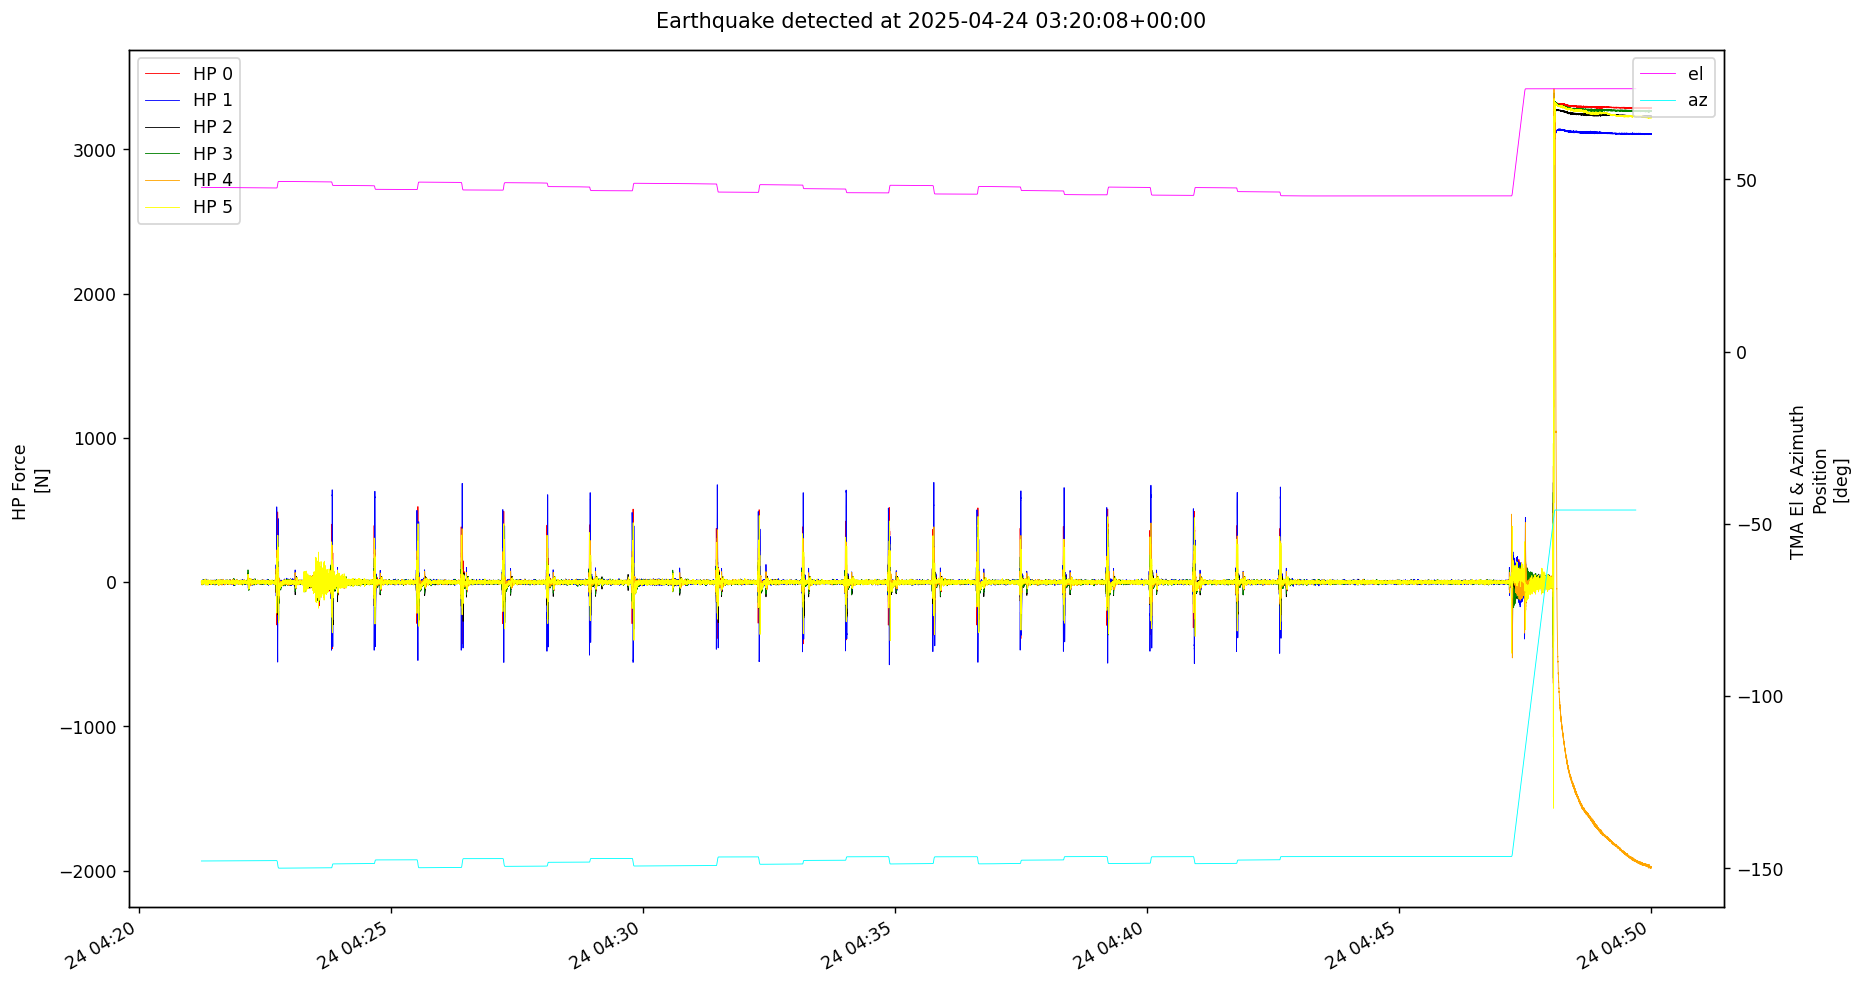

In [31]:
%matplotlib inline
compare_mount_hardpoints(
    df_mtmount_ele,
    df_mtmount_azi,
    df_hp,
    t1,
    t2
)

In [25]:
def compare_mount_hardpoints_separate_plots(
    df_mtmount_ele,
    df_mtmount_azi,
    df_hp,
    begin,
    end,
):
    fig, axs = plt.subplots(3, 1, dpi=125, figsize=(15, 8))
    ax = axs[0]
    df_plot = df_hp["measuredForce0"][begin:end]
    ax.plot(df_plot, color="red", lw="0.5", label="HP 0")
    df_plot = df_hp["measuredForce1"][begin:end]
    ax.plot(df_plot, color="blue", lw="0.5", label="HP 1")
    df_plot = df_hp["measuredForce2"][begin:end]
    ax.plot(df_plot, color="black", lw="0.5", label="HP 2")
    df_plot = df_hp["measuredForce3"][begin:end]
    ax.plot(df_plot, color="green", lw="0.5", label="HP 3")
    df_plot = df_hp["measuredForce4"][begin:end]
    ax.plot(df_plot, color="orange", lw="0.5", label="HP 4")
    df_plot = df_hp["measuredForce5"][begin:end]
    ax.plot(df_plot, color="yellow", lw="0.5", label="HP 5")
    ax.set_ylabel("HP Force \n[N]")

    ax = axs[1]
    df_plot = df_mtmount_ele["actualPosition"][begin:end]
    ax.plot(df_plot, color="green", lw="0.5")
    ax.set_ylabel("TMA Elevation \nPosition\n[deg]")
    # ax.axvline(begin, lw="0.5", c="k", label="Slew start")
    # ax.axvline(end, lw="0.5", c="b", label="Slew stop")

    ax = axs[2]
    df_plot = df_mtmount_azi["actualPosition"][begin:end]
    ax.plot(df_plot, color="red", lw="0.5")
    ax.set_ylabel("TMA Azimuth \nPosition\n[deg]")

    ax.set_xlabel("UTC")
    fig.autofmt_xdate()
    fig.subplots_adjust(hspace=1)
    fig.suptitle(t0)
    fig.legend()
    fig.tight_layout()

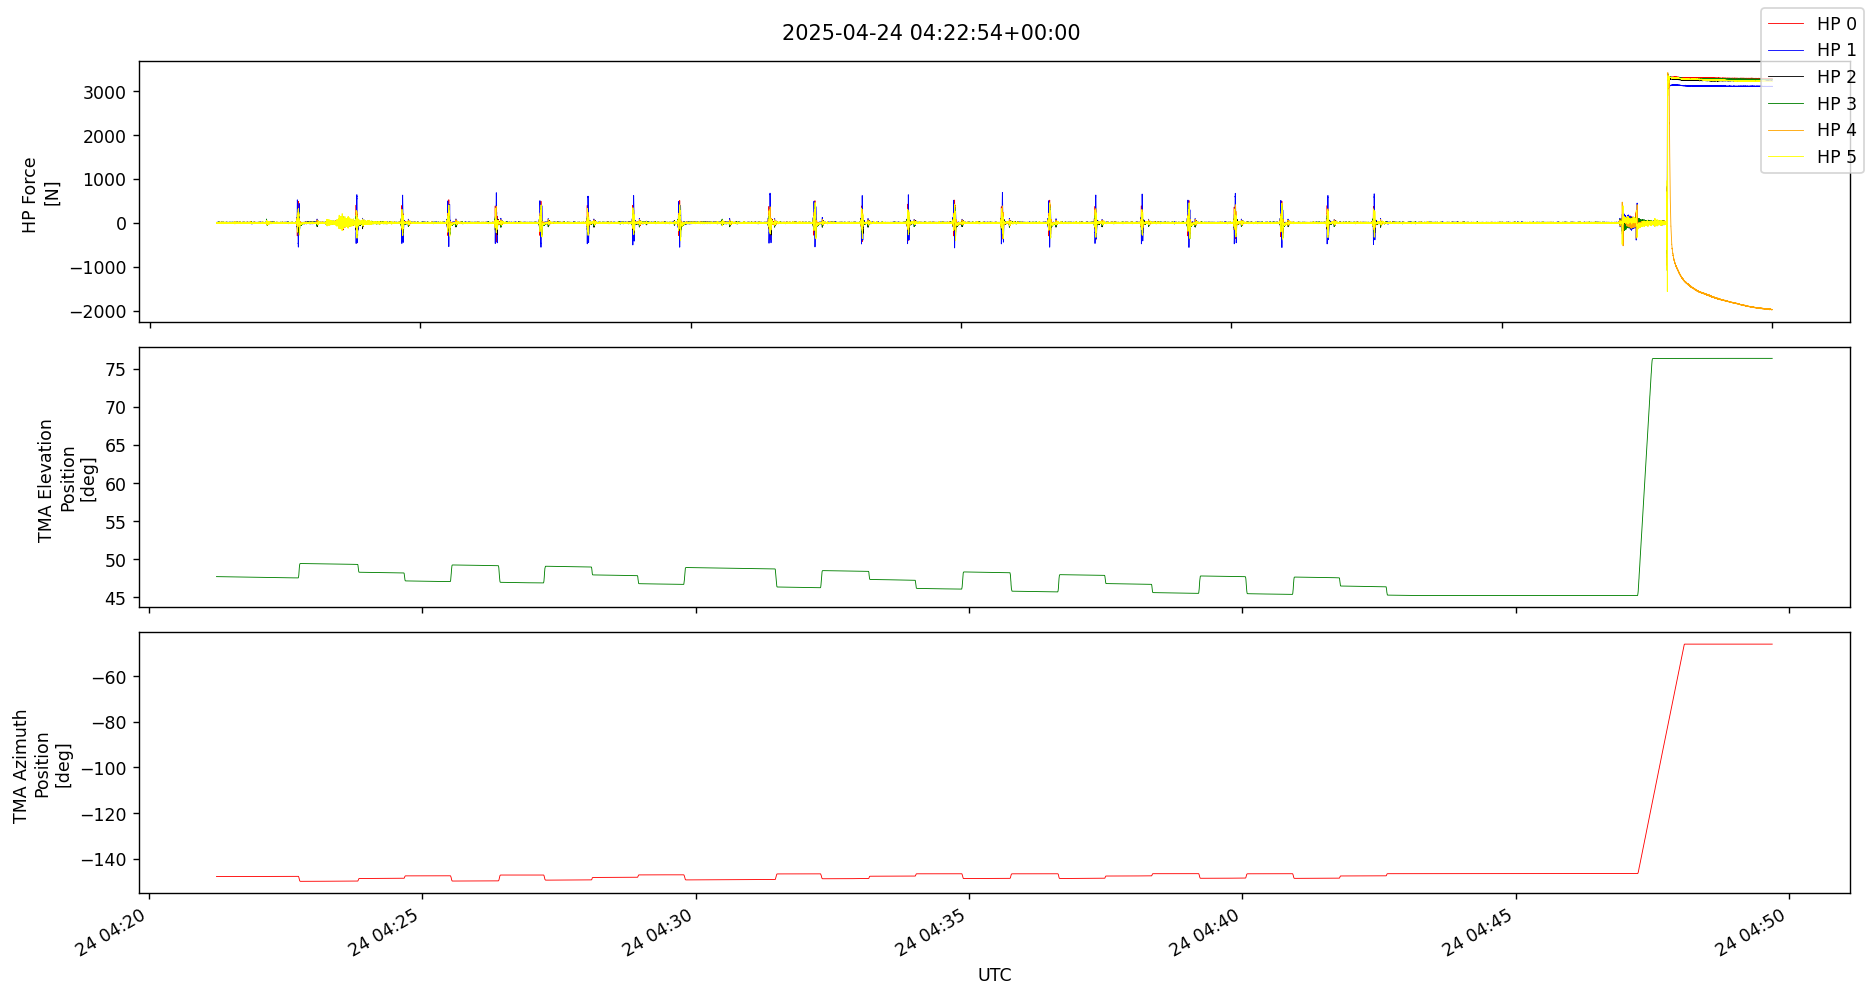

In [26]:
%matplotlib inline
compare_mount_hardpoints_separate_plots(
    df_mtmount_ele,
    df_mtmount_azi,
    df_hp,
    t1,
    t2,
)

In [36]:
def compare_mount_hardpoints_five_separate_plots(
    df_mtmount_ele,
    df_mtmount_azi,
    df_hp,
    begin,
    end,
):
    fig, axs = plt.subplots(6, 1, dpi=125, figsize=(20, 8))
    ax = axs[0]
    df_plot = df_hp["measuredForce0"][begin:end]
    ax.plot(df_plot, color="red", lw="0.5", label="HP 0")
    ax.set_ylabel("HP Force \n[N]")
    ax = axs[1]
    df_plot = df_hp["measuredForce1"][begin:end]
    ax.plot(df_plot, color="blue", lw="0.5", label="HP 1")
    ax.set_ylabel("HP Force \n[N]")
    ax = axs[2]
    df_plot = df_hp["measuredForce2"][begin:end]
    ax.plot(df_plot, color="black", lw="0.5", label="HP 2")
    ax.set_ylabel("HP Force \n[N]")
    ax = axs[3]
    df_plot = df_hp["measuredForce3"][begin:end]
    ax.plot(df_plot, color="green", lw="0.5", label="HP 3")
    ax.set_ylabel("HP Force \n[N]")
    ax = axs[4]
    df_plot = df_hp["measuredForce4"][begin:end]
    ax.plot(df_plot, color="orange", lw="0.5", label="HP 4")
    ax.set_ylabel("HP Force \n[N]")
    ax = axs[5]
    df_plot = df_hp["measuredForce5"][begin:end]
    ax.plot(df_plot, color="magenta", lw="0.5", label="HP 5")
    ax.set_ylabel("HP Force \n[N]")

    ax.set_xlabel("UTC")
    fig.autofmt_xdate()
    fig.subplots_adjust(hspace=1)
    fig.suptitle(t0)
    fig.legend()
    fig.tight_layout()

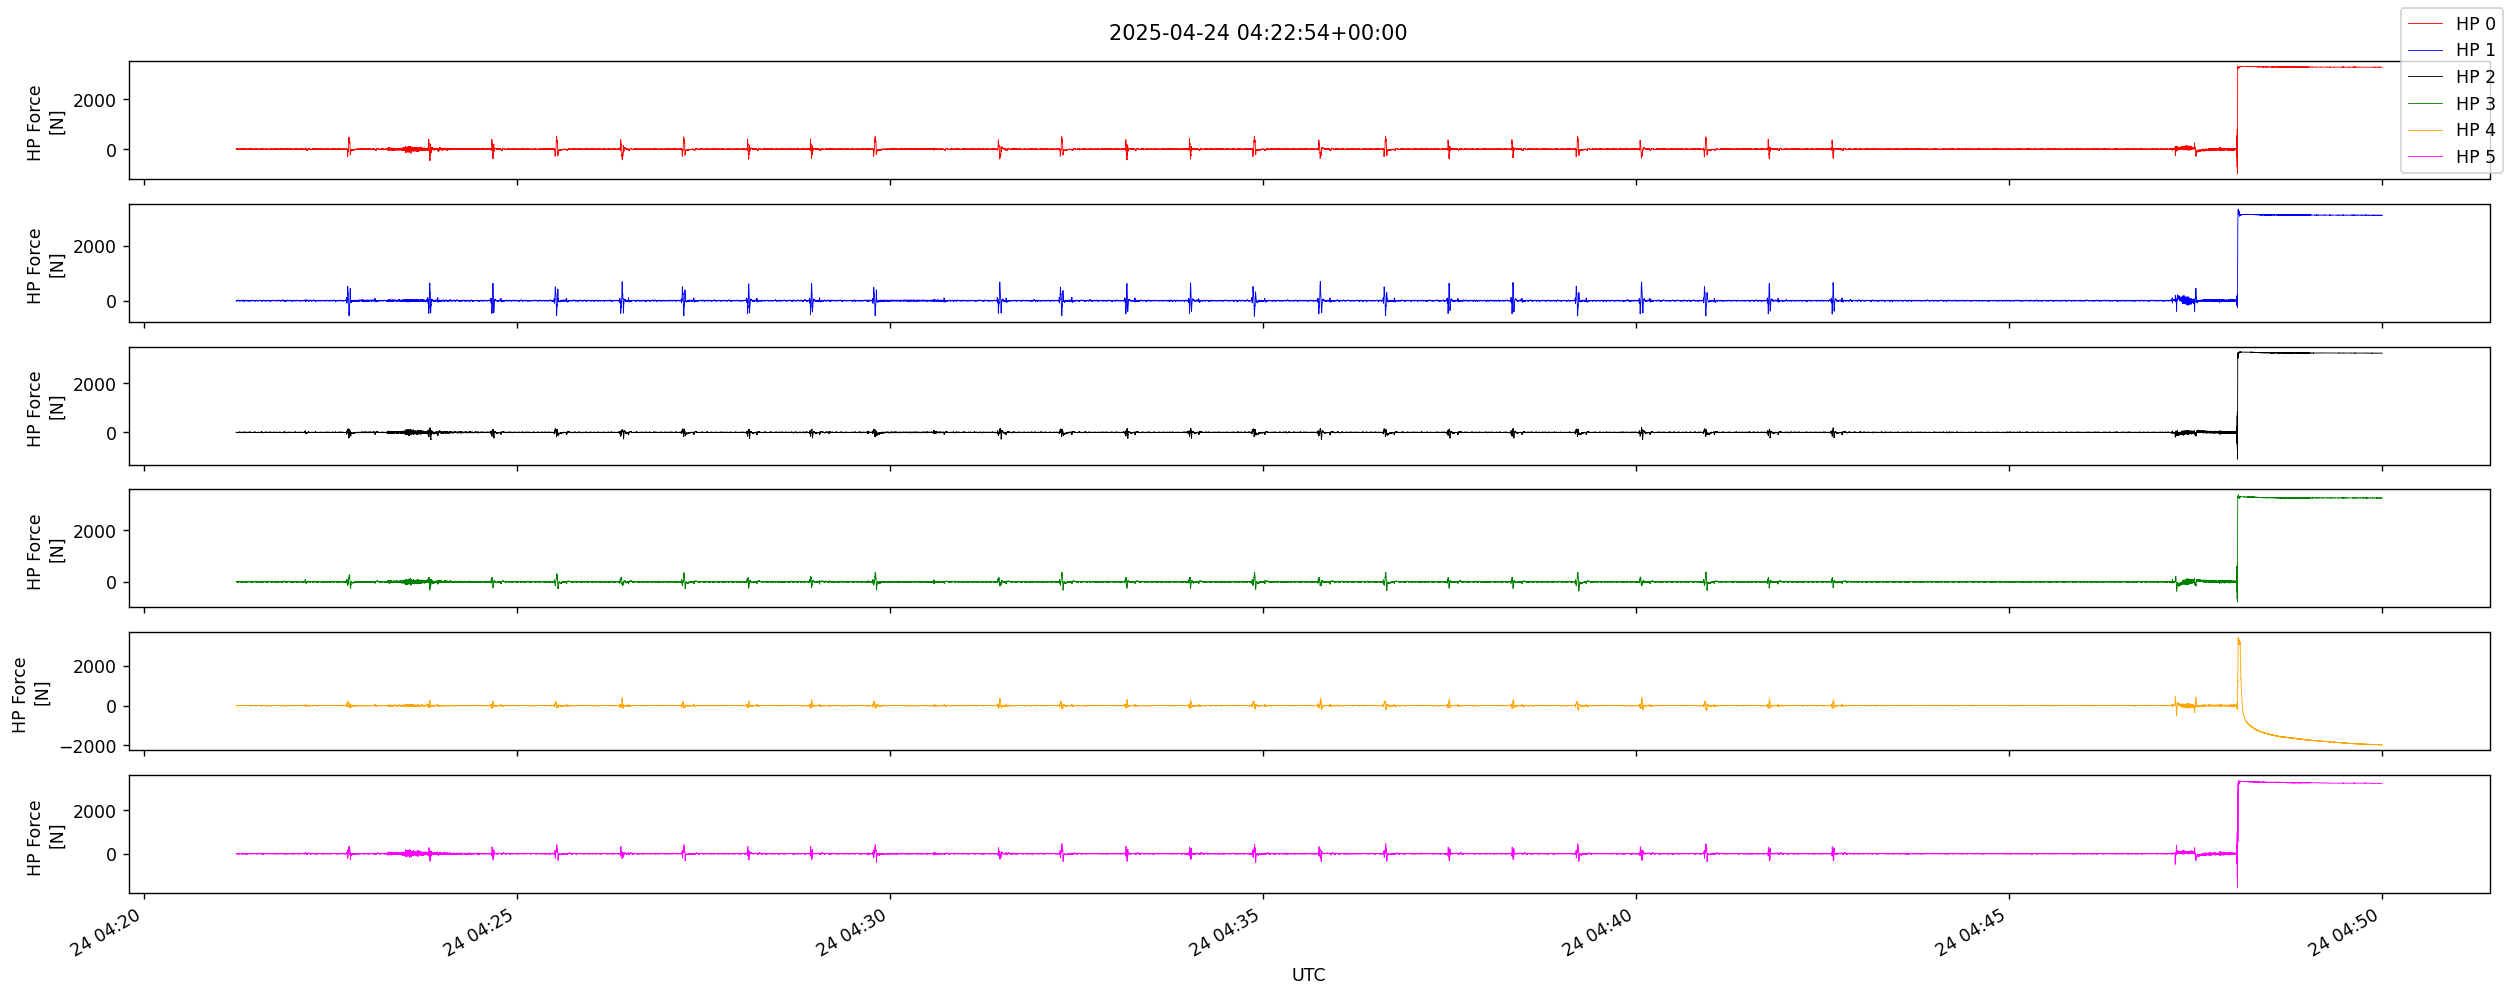

In [37]:
%matplotlib inline
compare_mount_hardpoints_five_separate_plots(
    df_mtmount_ele,
    df_mtmount_azi,
    df_hp,
    t1,
    t2,
)